<a href="https://colab.research.google.com/github/durgaprasadmadupu/Retail-Sales-Performance-Analysis/blob/main/sales_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dataset Loaded Successfully
Shape: (30000, 11)


,Store ID,Product ID,Date,Units Sold,Sales Revenue (USD),Discount Percentage,Marketing Spend (USD),Store Location,Product Category,Day of the Week,Holiday Effect
0,Spearsland,52372247,2022-01-01,9,2741.69,20,81,Tanzania,Furniture,Saturday,False
1,Spearsland,52372247,2022-01-02,7,2665.53,0,0,Mauritania,Furniture,Sunday,False
2,Spearsland,52372247,2022-01-03,1,380.79,0,0,Saint Pierre and Miquelon,Furniture,Monday,False
3,Spearsland,52372247,2022-01-04,4,1523.16,0,0,Australia,Furniture,Tuesday,False
4,Spearsland,52372247,2022-01-05,2,761.58,0,0,Swaziland,Furniture,Wednesday,False



--- Data Cleaning ---
✅ Cleaned Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Store ID               30000 non-null  object        
 1   Product ID             30000 non-null  int64         
 2   OrderDate              30000 non-null  datetime64[ns]
 3   Quantity               30000 non-null  int64         
 4   Sales                  30000 non-null  float64       
 5   Discount Percentage    30000 non-null  int64         
 6   Marketing Spend (USD)  30000 non-null  int64         
 7   Region                 30000 non-null  object        
 8   Category               30000 non-null  object        
 9   Day of the Week        30000 non-null  object        
 10  Holiday Effect         30000 non-null  bool          
 11  Month                  30000 non-null  object        
 12  Quarter           

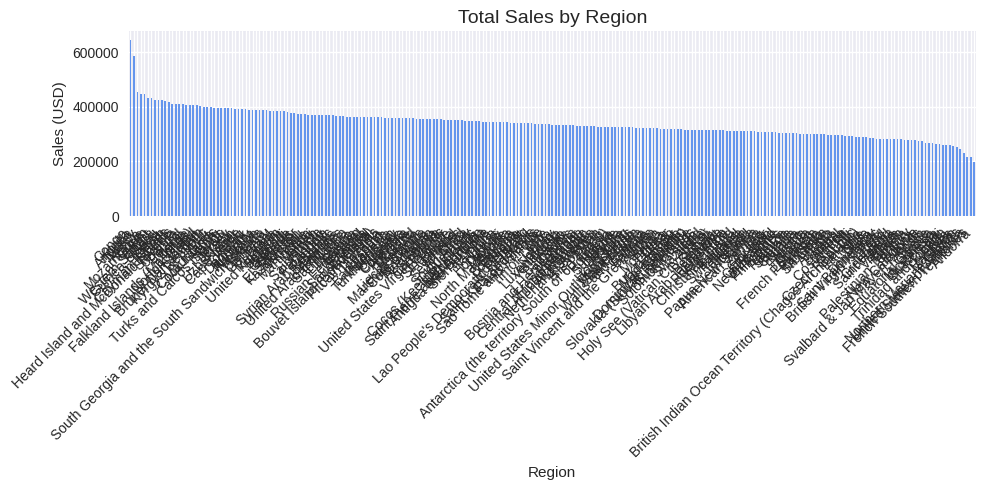

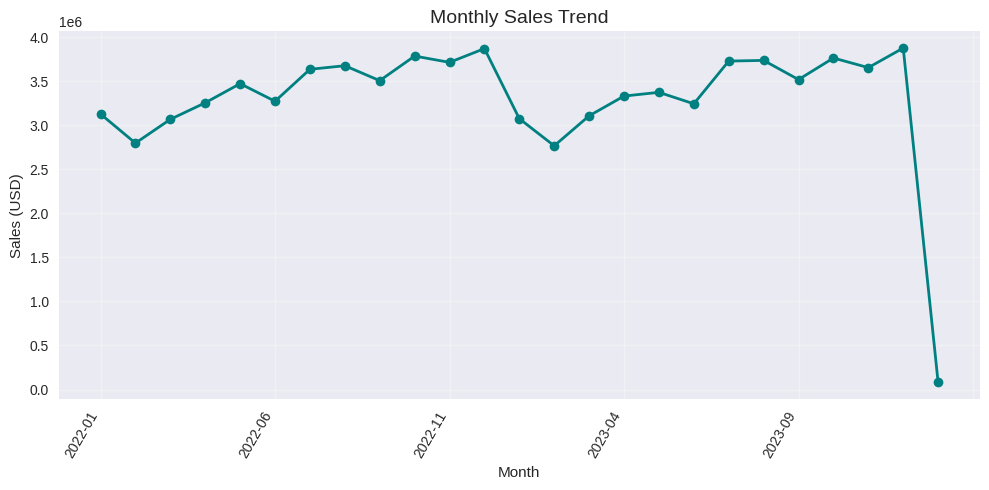

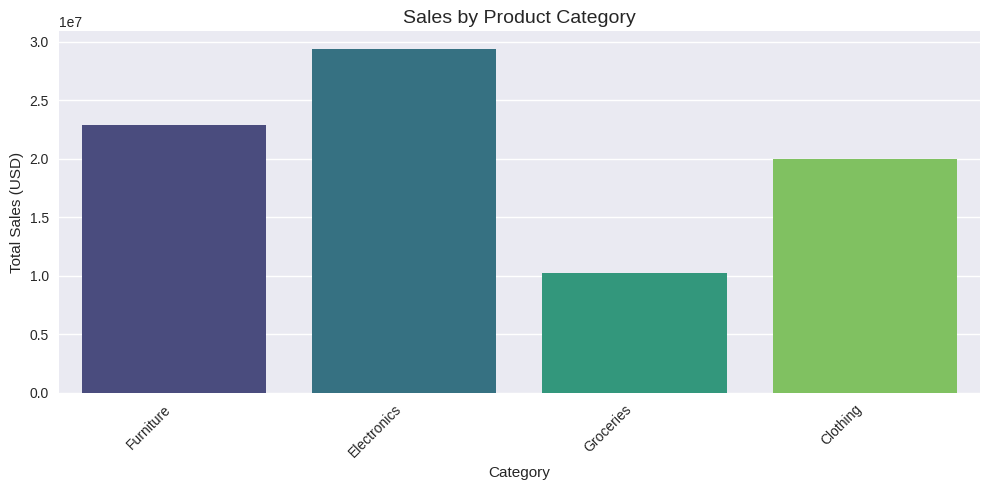

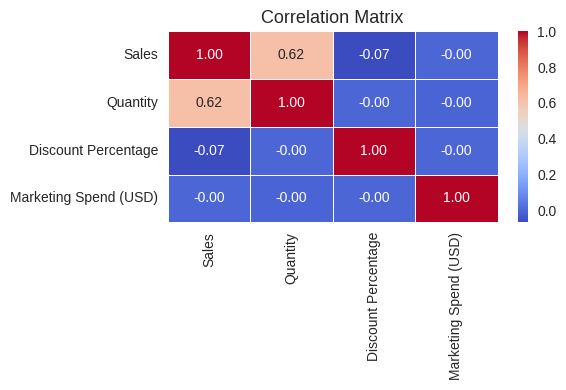

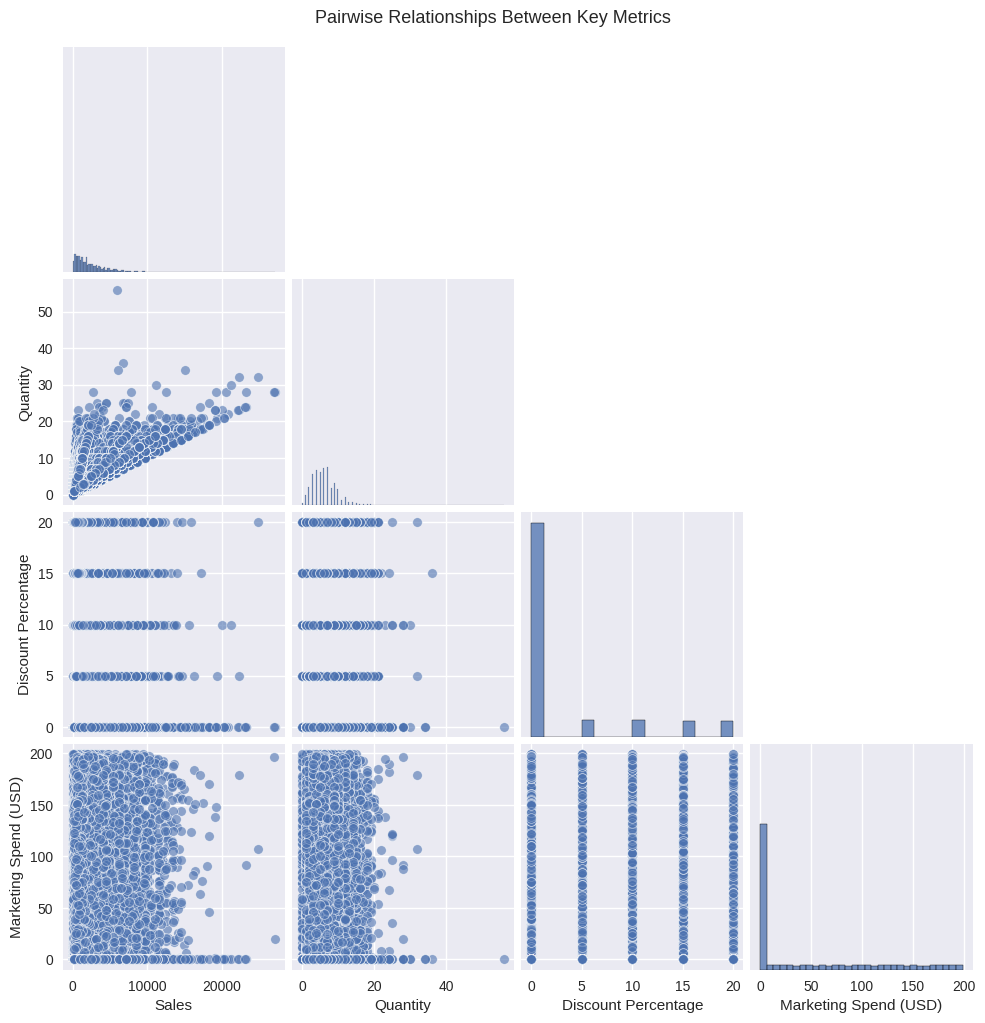


--- Interactive Dashboard (Plotly) ---



--- Predictive Modeling ---

--- Model Evaluation ---
Linear Regression    → R²: 0.3835, RMSE: 2034.01
Ridge Regression     → R²: 0.3835, RMSE: 2034.01
Lasso Regression     → R²: 0.3835, RMSE: 2034.01

--- Forecast Visualization ---



--- Feature Importance ---



✅ Analysis complete. Results saved to: /content/predicted_sales_results.csv


In [9]:
# ==========================================
# Retail Sales Performance Analysis
# Author: Durga Prasad Madupu
# Client: Internal – Glad Power
# Manager: Sindhoori Kashetti
# Technologies: Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly, scikit-learn
# ==========================================

# --- 1. Install & Import Libraries ---
!pip install plotly seaborn scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# --- 2. Load Dataset ---
df = pd.read_csv('/content/Retail_sales.csv')
print("✅ Dataset Loaded Successfully")
print("Shape:", df.shape)
display(df.head())

# --- 3. Data Cleaning ---
print("\n--- Data Cleaning ---")

# Rename columns for consistency
df.rename(columns={
    'Date': 'OrderDate',
    'Sales Revenue (USD)': 'Sales',
    'Units Sold': 'Quantity',
    'Product Category': 'Category',
    'Store Location': 'Region'
}, inplace=True)

# Convert date and handle nulls
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df.dropna(subset=['OrderDate'], inplace=True)

# Extract Month and Quarter
df['Month'] = df['OrderDate'].dt.to_period('M').astype(str)
df['Quarter'] = df['OrderDate'].dt.to_period('Q').astype(str)

print("✅ Cleaned Dataset:")
print(df.info())

# --- 4. Exploratory Data Analysis (Improved Visuals) ---
plt.style.use('seaborn-v0_8')
print("\n--- Exploratory Data Analysis ---")

# Total Sales by Region
plt.figure(figsize=(10,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='cornflowerblue')
plt.title('Total Sales by Region', fontsize=14)
plt.ylabel('Sales (USD)')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Monthly Sales Trend
plt.figure(figsize=(10,5))
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(color='teal', marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=60, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Category-wise Sales Comparison
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, ci=None, palette='viridis')
plt.title('Sales by Product Category', fontsize=14)
plt.ylabel('Total Sales (USD)')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(6,4))
num_cols = ['Sales', 'Quantity', 'Discount Percentage', 'Marketing Spend (USD)']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Pairplot for Key Numeric Metrics
sns.pairplot(df[num_cols], corner=True, plot_kws={'alpha':0.6})
plt.suptitle('Pairwise Relationships Between Key Metrics', y=1.02, fontsize=13)
plt.show()

# --- 5. Interactive Dashboard (Plotly) ---
print("\n--- Interactive Dashboard (Plotly) ---")

# Sales by Category and Region
fig = px.bar(df, x='Category', y='Sales', color='Region', barmode='group',
             title='Sales by Category and Region',
             hover_data=['Discount Percentage', 'Marketing Spend (USD)'])
fig.show()

# Monthly Sales Interactive Line Chart (Fix Period issue)
monthly_df = df.groupby(['Month', 'Region'], as_index=False)['Sales'].sum()
monthly_df['Month'] = pd.to_datetime(monthly_df['Month'])
fig2 = px.line(monthly_df, x='Month', y='Sales', color='Region',
               title='Monthly Sales by Region')
fig2.update_xaxes(dtick="M1", tickformat="%b %Y")
fig2.show()

# --- 6. Predictive Modeling ---
print("\n--- Predictive Modeling ---")

# Feature Engineering
df['MonthNum'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

X = df[['MonthNum', 'Year', 'Quantity', 'Discount Percentage', 'Marketing Spend (USD)']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Ridge Regression
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso Regression
lasso = Lasso(alpha=0.001).fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# --- 7. Model Evaluation ---
print("\n--- Model Evaluation ---")

def evaluate_model(name, y_true, y_pred):
    print(f"{name:20s} → R²: {r2_score(y_true, y_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)

# --- 8. Forecast Visualization ---
print("\n--- Forecast Visualization ---")

test_df = X_test.copy()
test_df['Actual'] = y_test
test_df['Predicted'] = y_pred_ridge

# Actual vs Predicted
fig3 = px.scatter(test_df, x='Actual', y='Predicted',
                  title='Actual vs Predicted Sales (Ridge Regression)',
                  color_discrete_sequence=['#0083B8'])
fig3.add_shape(type='line',
               x0=test_df['Actual'].min(), y0=test_df['Actual'].min(),
               x1=test_df['Actual'].max(), y1=test_df['Actual'].max(),
               line=dict(color='red', dash='dash'))
fig3.show()

# Forecast Trend
test_df = test_df.sort_values('Actual')
fig4 = px.line(test_df, y=['Actual', 'Predicted'],
               title='Forecast vs Actual Sales', markers=True)
fig4.show()

# --- 9. Feature Importance ---
print("\n--- Feature Importance ---")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

fig5 = px.bar(coef_df, x='Feature', y='Coefficient',
              title='Feature Importance (Ridge Regression)', color='Coefficient',
              color_continuous_scale='bluered')
fig5.show()

# --- 10. Save Results ---
output_path = '/content/predicted_sales_results.csv'
test_df.to_csv(output_path, index=False)
print(f"\n✅ Analysis complete. Results saved to: {output_path}")
